# 02 — Model Experiments & Visualization

In [103]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Run Pipeline

In [104]:
from src.data.download import load_or_download
from src.data.validation import validate_and_clean_data
from src.data.external_signals import get_external_signals
from src.features.engineering import engineer_features_ml_ready
from src.features.selection import (
    correlation_feature_selection, tree_based_feature_selection
)
from src.pipeline.split import train_test_split_pipeline
from src.models.regime import detect_market_regimes_hmm, extract_posteriors
from src.models.train import run_optuna_hpo, train_and_evaluate

df_raw      = load_or_download()
df_cleaned  = validate_and_clean_data(df_raw)
df_external = get_external_signals()
df_ml       = engineer_features_ml_ready(df_cleaned, df_external)

X_train, X_test, y_train, y_test, dta_threshold = train_test_split_pipeline(df_ml)

X_train_r, X_test_r, _ = correlation_feature_selection(X_train, X_test)
X_train_f, X_test_f, selected_features, importance_df = \
    tree_based_feature_selection(X_train_r, X_test_r, y_train)

X_train_reg, X_test_reg, hmm_model, transition_matrix = \
    detect_market_regimes_hmm(X_train_f, X_test_f)

train_post, test_post = extract_posteriors(hmm_model, X_train_f, X_test_f)
X_train_soft = pd.concat([X_train_f, train_post], axis=1)
X_test_soft  = pd.concat([X_test_f,  test_post],  axis=1)

best_params = run_optuna_hpo(X_train_soft, y_train)
summary_df, results, models = train_and_evaluate(
    X_train_soft, X_test_soft, X_train_f, X_test_f,
    y_train, y_test, best_params
)
print(summary_df)

✅ Loaded cached data from bitcoin_daily_data.csv  (2,260 rows)
DATA INTEGRITY AUDIT
Initial rows : 2,260
Date range   : 2020-01-01 00:00:00 → 2026-03-09 00:00:00
OHLC relationships valid.
No missing daily timestamps detected.

Return distribution summary:
count    2259.000000
mean        0.001528
std         0.032368
min        -0.395048
25%        -0.012907
50%         0.000329
75%         0.015136
max         0.195361
Name: returns, dtype: float64
Final rows : 2,260
FETCHING EXTERNAL SIGNALS
Period : 2020-01-01  →  2026-05-23

[1/3] Fear & Greed Index  (alternative.me) ...
   ✅ 3,030 obs  |  2018-02-01 → 2026-05-23

[2/3] S&P 500  (^GSPC, yfinance) ...
   ✅ 1,606 obs  |  2020-01-02 → 2026-05-22

[3/3] VIX  (^VIX, yfinance) ...
   ✅ 1,606 obs  |  2020-01-02 → 2026-05-22

[4/4] Merging signals onto full daily calendar ...

EXTERNAL SIGNALS — INTEGRITY REPORT
  Shape      : (2335, 3)
  Date range : 2020-01-01 → 2026-05-23

  Remaining NaNs (after fill policy):
    ✅ fear_greed      : 0


## 2. Selected Features — Group Breakdown

SELECTED FEATURES — GROUP BREAKDOWN
  Total selected : 8

  [Momentum]  (4 features)
    • momentum_60d                    MDI=0.0375  PI=0.0016
    • momentum_5d                     MDI=0.0344  PI=-0.0050
    • momentum_21d                    MDI=0.0291  PI=0.0023
    • fg_momentum                     MDI=0.0227  PI=-0.0027

  [Technical]  (1 features)
    • bb_zscore_20                    MDI=0.0309  PI=-0.0047

  [Time]  (1 features)
    • day_of_week                     MDI=0.0247  PI=-0.0009

  [External]  (3 features)
    • spx_5d_return                   MDI=0.0310  PI=-0.0011
    • vix_change                      MDI=0.0252  PI=-0.0037
    • fg_momentum                     MDI=0.0227  PI=-0.0027



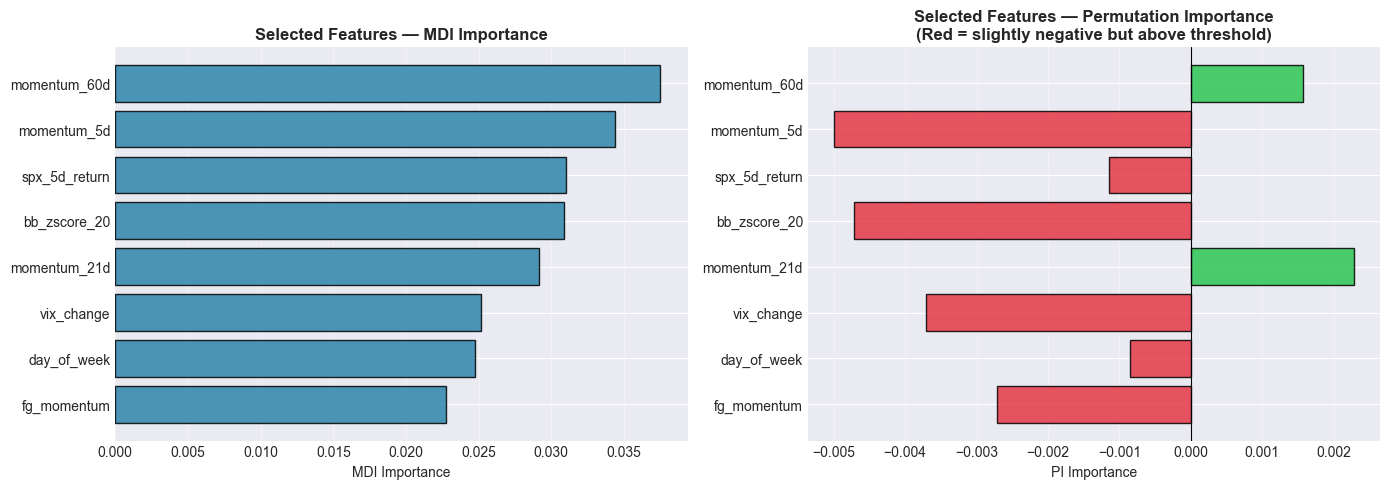

In [105]:
feature_groups = {
    'Momentum':     [f for f in selected_features if 'momentum' in f],
    'Volatility':   [f for f in selected_features if 'vol' in f],
    'Technical':    [f for f in selected_features if any(x in f for x in
                     ['rsi', 'macd', 'bb_', 'ma_', 'price_to_ema'])],
    'Volume':       [f for f in selected_features if any(x in f for x in
                     ['volume', 'vwap', 'price_to_vwap'])],
    'Price Action': [f for f in selected_features if f in ['body_ratio', 'hl_range']],
    'Time':         [f for f in selected_features if f in ['day_of_week', 'month', 'quarter']],
    'External':     [f for f in selected_features if any(x in f for x in
                     ['fg_', 'vix_', 'spx_'])],
    'Regime':       [f for f in selected_features if f == 'vol_spike'],
}

print('=' * 60)
print('SELECTED FEATURES — GROUP BREAKDOWN')
print('=' * 60)
print(f'  Total selected : {len(selected_features)}')
print()

for group, feats in feature_groups.items():
    if feats:
        print(f'  [{group}]  ({len(feats)} features)')
        for f in feats:
            mdi = importance_df.loc[f, 'mdi_importance']
            pi  = importance_df.loc[f, 'pi_importance']
            print(f'    • {f:<30}  MDI={mdi:.4f}  PI={pi:.4f}')
        print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_sel = importance_df[importance_df['retained']].sort_values('mdi_importance', ascending=True)

axes[0].barh(imp_sel.index, imp_sel['mdi_importance'],
             color='#2E86AB', alpha=0.85, edgecolor='black')
axes[0].set_title('Selected Features — MDI Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MDI Importance')
axes[0].grid(axis='x', alpha=0.3)

pi_colors = ['#E63946' if v < 0 else '#2dc653' for v in imp_sel['pi_importance']]
axes[1].barh(imp_sel.index, imp_sel['pi_importance'],
             color=pi_colors, alpha=0.85, edgecolor='black')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Selected Features — Permutation Importance\n(Red = slightly negative but above threshold)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('PI Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3 HMM Regime Visualization — Test Period


HMM Transition Matrix:
               To Low Vol  To Mid Vol  To High Vol
From Low Vol        0.924       0.063        0.013
From Mid Vol        0.034       0.935        0.031
From High Vol       0.027       0.045        0.928

Diagonal dominance = volatility clustering (Mandelbrot 1963)


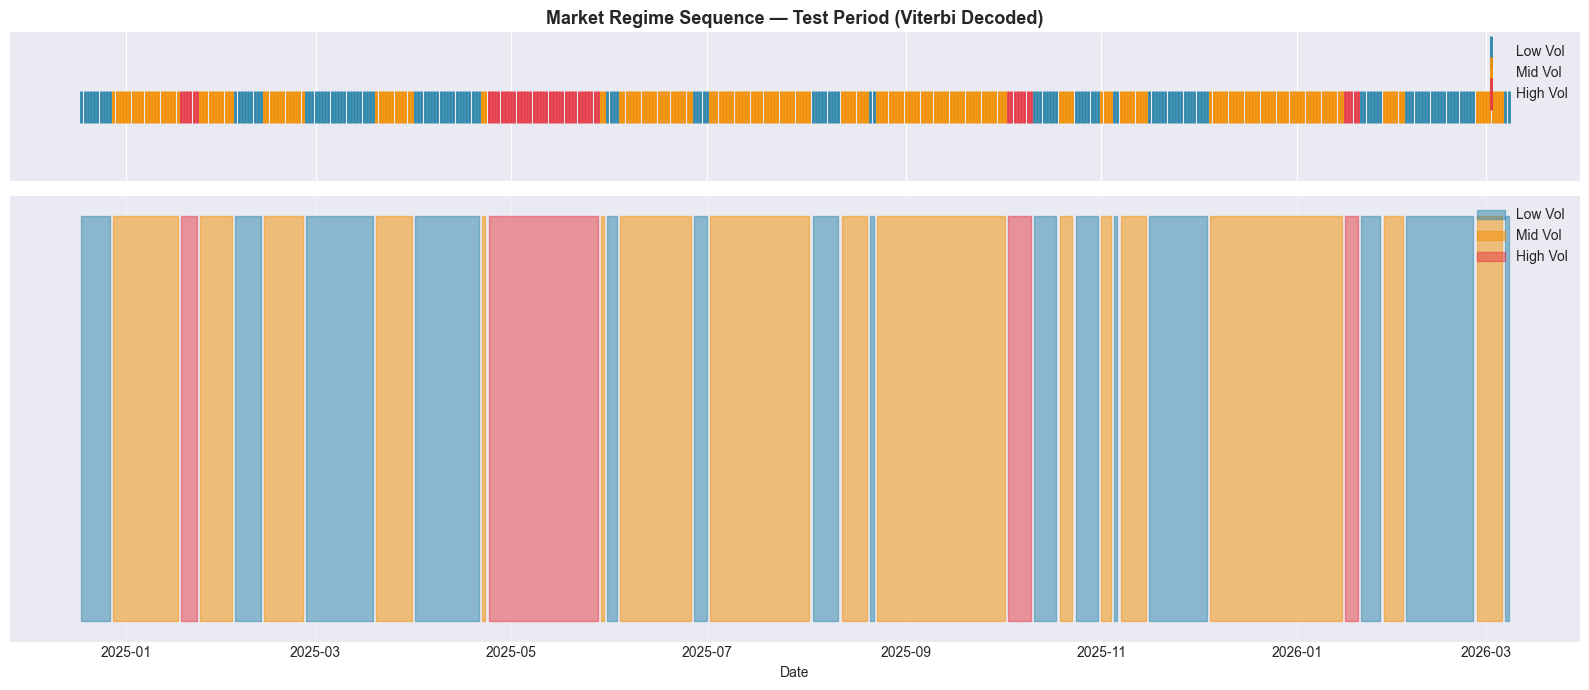

In [106]:
COLORS       = ['#2E86AB', '#F18F01', '#E63946']
REGIME_NAMES = {0: 'Low Vol', 1: 'Mid Vol', 2: 'High Vol'}
test_regimes = X_test_reg['regime'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})

for i in range(3):
    mask = test_regimes == i
    axes[0].scatter(X_test_f.index[mask], [1]*mask.sum(),
                    color=COLORS[i], marker='|', s=500, linewidths=2,
                    label=REGIME_NAMES[i])
axes[0].set_title('Market Regime Sequence — Test Period (Viterbi Decoded)',
                   fontsize=13, fontweight='bold')
axes[0].set_yticks([])
axes[0].legend(loc='upper right')

for i in range(3):
    mask = test_regimes == i
    axes[1].fill_between(X_test_f.index, 0, 1, where=mask,
                          color=COLORS[i], alpha=0.5, label=REGIME_NAMES[i])
axes[1].set_xlabel('Date')
axes[1].set_yticks([])
axes[1].legend(loc='upper right')
axes[1].grid(axis='x', alpha=0.3)

# Transition matrix
print('\nHMM Transition Matrix:')
print(transition_matrix.round(3).to_string())
print('\nDiagonal dominance = volatility clustering (Mandelbrot 1963)')

plt.tight_layout()
plt.show()

## 4. Model Progression — LR → Global LGBM → Soft-Regime LGBM

Per-class F1 scores:
                       Short  Neutral    Long   Macro
LR Baseline           0.1935   0.5709  0.0990  0.2878
LightGBM Global       0.1239   0.7994  0.1163  0.3465
LightGBM Soft-Regime  0.1481   0.8159  0.1282  0.3641

Delta (LightGBM Soft-Regime − LightGBM Global):
  Short       +0.0243
  Neutral     +0.0164
  Long        +0.0119
  Macro       +0.0175


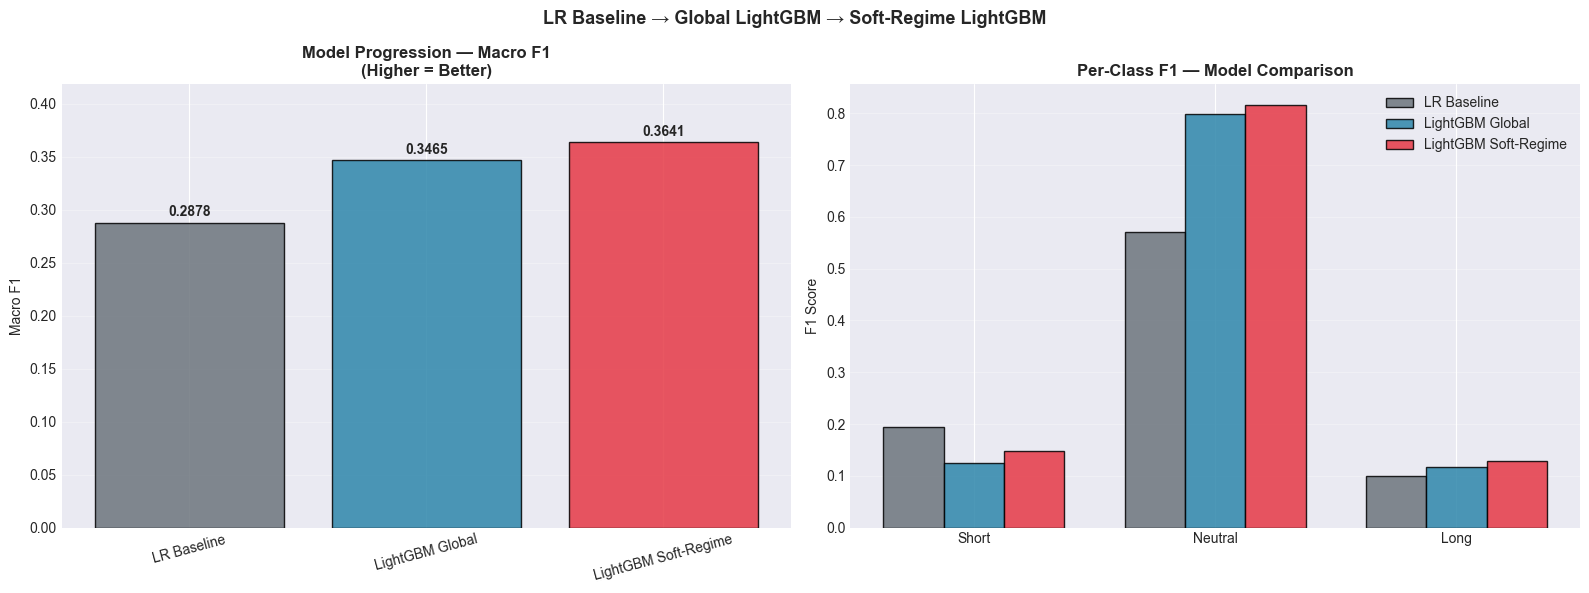

In [107]:
model_names = list(results.keys())
model_colors = ['#6c757d', '#2E86AB', '#E63946']

# --- Macro F1 per model ---
macro_f1_scores = {
    name: f1_score(y_test, pred, average='macro', zero_division=0)
    for name, pred in results.items()
}

# --- Per-class F1 ---
per_class_f1 = {}
for name, pred in results.items():
    report = classification_report(y_test, pred,
                                   labels=[-1, 0, 1],
                                   target_names=['Short', 'Neutral', 'Long'],
                                   output_dict=True, zero_division=0)
    per_class_f1[name] = {
        'Short':   report['Short']['f1-score'],
        'Neutral': report['Neutral']['f1-score'],
        'Long':    report['Long']['f1-score'],
        'Macro':   report['macro avg']['f1-score'],
    }

per_class_df = pd.DataFrame(per_class_f1).T
print('Per-class F1 scores:')
print(per_class_df.round(4).to_string())

# --- Delta table ---
model_list = list(per_class_f1.keys())
if len(model_list) >= 3:
    global_name = model_list[1]
    soft_name   = model_list[2]
    print(f'\nDelta ({soft_name} − {global_name}):')
    for cls in ['Short', 'Neutral', 'Long', 'Macro']:
        delta = per_class_f1[soft_name][cls] - per_class_f1[global_name][cls]
        sign  = '+' if delta >= 0 else ''
        print(f'  {cls:<10}  {sign}{delta:.4f}')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Macro F1 progression
bars = axes[0].bar(model_names,
                   [macro_f1_scores[n] for n in model_names],
                   color=model_colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, macro_f1_scores.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Model Progression — Macro F1\n(Higher = Better)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Macro F1')
axes[0].set_ylim(0, max(macro_f1_scores.values()) * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# Panel 2: Per-class F1 grouped bar
x      = np.arange(3)
width  = 0.25
labels = ['Short', 'Neutral', 'Long']

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    vals = [per_class_f1[name][cls] for cls in labels]
    axes[1].bar(x + i*width, vals, width, label=name,
                color=color, alpha=0.85, edgecolor='black')

axes[1].set_title('Per-Class F1 — Model Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(labels)
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('LR Baseline → Global LightGBM → Soft-Regime LightGBM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

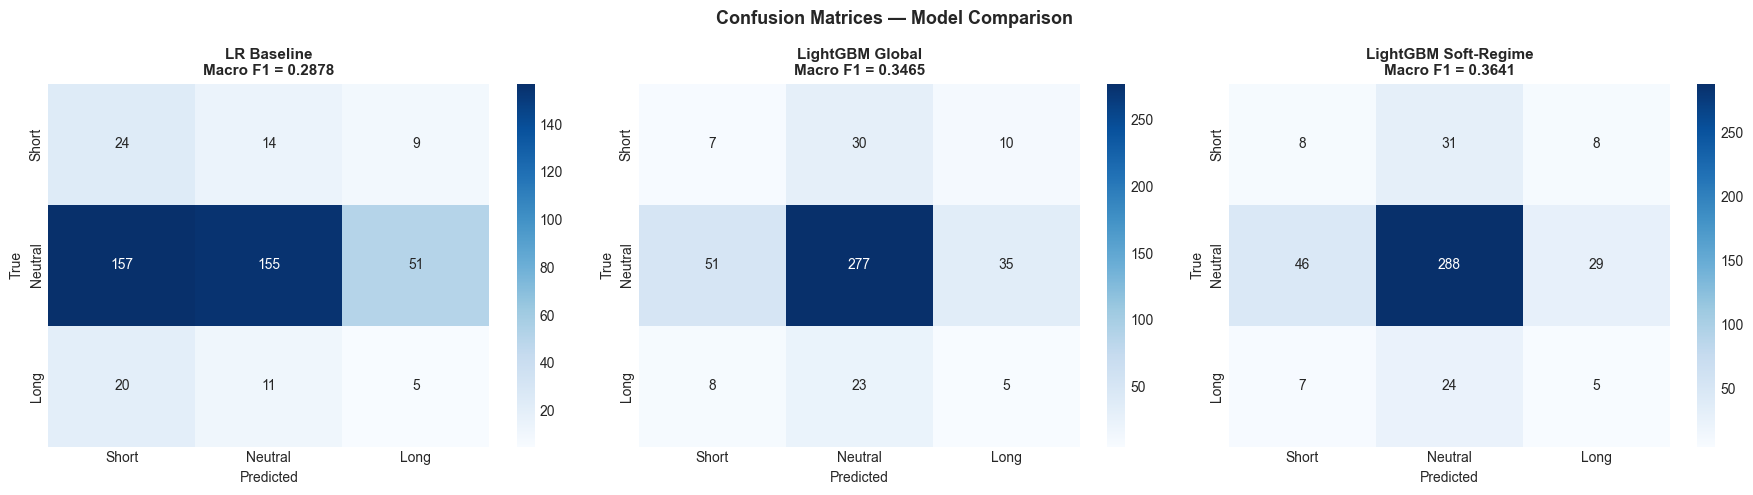

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, results.items()):
    cm  = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
    mf1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Short', 'Neutral', 'Long'],
                yticklabels=['Short', 'Neutral', 'Long'])
    ax.set_title(f'{name}\nMacro F1 = {mf1:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. HMM Posterior Feature Importance

HMM Posterior Feature Ranks (out of 11 features):

  p_low_vol             rank 10/11   importance=665
  p_mid_vol             rank  7/11   importance=804
  p_high_vol            rank  8/11   importance=762


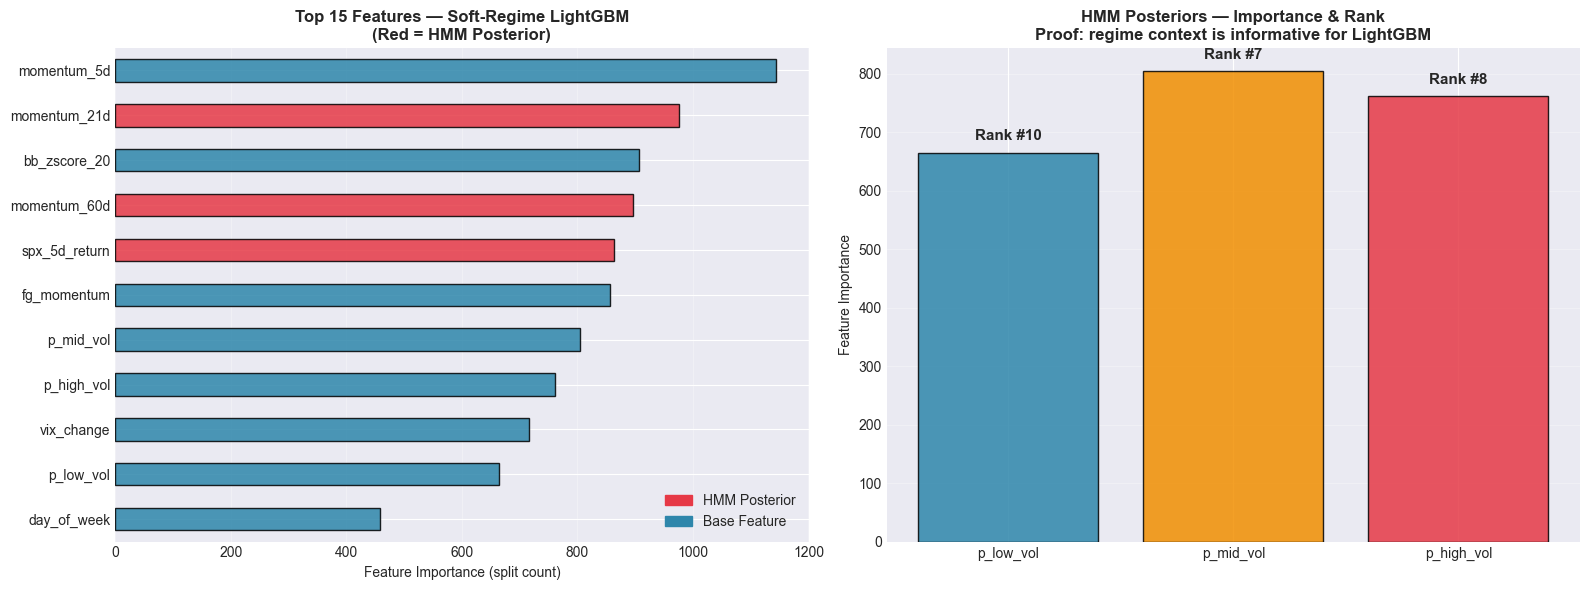

In [109]:
lgbm_soft = models['LightGBM Soft-Regime']
imp_soft  = pd.Series(lgbm_soft.feature_importances_,
                      index=X_train_soft.columns).sort_values(ascending=False)

post_cols = ['p_low_vol', 'p_mid_vol', 'p_high_vol']

print('HMM Posterior Feature Ranks (out of', len(imp_soft), 'features):')
print()
for col in post_cols:
    rank = list(imp_soft.index).index(col) + 1
    val  = imp_soft[col]
    print(f'  {col:<20}  rank {rank:>2}/{len(imp_soft)}   importance={val}')

# Plot: posterior importance vs base features
top_n       = 15
imp_top     = imp_soft.head(top_n)
bar_colors  = ['#E63946' if f in post_cols else '#2E86AB' for f in imp_top.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top features colored by posterior vs base
imp_top.plot.barh(ax=axes[0], color=bar_colors[::-1], edgecolor='black', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel('Feature Importance (split count)')
axes[0].set_title(f'Top {top_n} Features — Soft-Regime LightGBM\n'
                   '(Red = HMM Posterior)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
red_patch   = mpatches.Patch(color='#E63946', label='HMM Posterior')
blue_patch  = mpatches.Patch(color='#2E86AB', label='Base Feature')
axes[0].legend(handles=[red_patch, blue_patch])

# Right: posterior importance only — bar chart
post_vals  = [imp_soft.get(c, 0) for c in post_cols]
post_ranks = [list(imp_soft.index).index(c) + 1 for c in post_cols]
bars = axes[1].bar(post_cols, post_vals,
                   color=['#2E86AB', '#F18F01', '#E63946'],
                   alpha=0.85, edgecolor='black')
for bar, rank, val in zip(bars, post_ranks, post_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(post_vals)*0.02,
                 f'Rank #{rank}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_title('HMM Posteriors — Importance & Rank\n'
                   'Proof: regime context is informative for LightGBM',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Feature Importance')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Walk-Forward Validation

WALK-FORWARD VALIDATION
  Initial train window : 24 months
  Step size            : 3 months
  Models               : LR | Global LGBM | Soft-Regime LGBM

  Total folds : 16
  Fold   Train start    Train end     Test end  Test days
  ----- ------------ ------------ ------------ ----------
  1       2020-03-02   2022-03-02   2022-06-02         92
  2       2020-03-02   2022-06-02   2022-09-02         92
  3       2020-03-02   2022-09-02   2022-12-02         91
  4       2020-03-02   2022-12-02   2023-03-02         90
  5       2020-03-02   2023-03-02   2023-06-02         92
  6       2020-03-02   2023-06-02   2023-09-02         92
  7       2020-03-02   2023-09-02   2023-12-02         91
  8       2020-03-02   2023-12-02   2024-03-02         91
  9       2020-03-02   2024-03-02   2024-06-02         92
  10      2020-03-02   2024-06-02   2024-09-02         92
  11      2020-03-02   2024-09-02   2024-12-02         91
  12      2020-03-02   2024-12-02   2025-03-02         90
  13      2020

Model is not converging.  Current: 10525.40288679237 is not greater than 10545.991202744666. Delta is -20.588315952296398



  Fold 2  [2022-06-02 → 2022-09-02]  n_test=92  thr=3.73%
    LR=0.3836  Global=0.4888  Soft=0.4958


Model is not converging.  Current: 1548.6508353385027 is not greater than 6372.371981587879. Delta is -4823.721146249377



  Fold 3  [2022-09-02 → 2022-12-02]  n_test=91  thr=3.69%
    LR=0.2763  Global=0.3098  Soft=0.3077

  Fold 4  [2022-12-02 → 2023-03-02]  n_test=90  thr=3.58%
    LR=0.2744  Global=0.3166  Soft=0.3166


...


  Fold 14  [2025-06-02 → 2025-09-02]  n_test=92  thr=3.00%
    LR=0.3291  Global=0.3182  Soft=0.3182


Model is not converging.  Current: 3222.2466922173758 is not greater than 19774.084205543917. Delta is -16551.83751332654



  Fold 15  [2025-09-02 → 2025-12-02]  n_test=91  thr=2.96%
    LR=0.3012  Global=0.3382  Soft=0.3449


Model is not converging.  Current: 3883.4930610309584 is not greater than 34606.217618838156. Delta is -30722.724557807196



  Fold 16  [2025-12-02 → 2026-03-02]  n_test=90  thr=2.88%
    LR=0.2422  Global=0.3268  Soft=0.2711

WALK-FORWARD RESULTS — FOLD-BY-FOLD
 fold  train_end   test_end  n_test  lr_macro_f1  global_macro_f1  soft_macro_f1
    1 2022-03-02 2022-06-02      92       0.3346           0.3889         0.4147
    2 2022-06-02 2022-09-02      92       0.3836           0.4888         0.4958
    3 2022-09-02 2022-12-02      91       0.2763           0.3098         0.3077
    4 2022-12-02 2023-03-02      90       0.2744           0.3166         0.3166
    5 2023-03-02 2023-06-02      92       0.2994           0.2949         0.2994
    6 2023-06-02 2023-09-02      92       0.3121           0.3142         0.3121
    7 2023-09-02 2023-12-02      91       0.3008           0.3056         0.4429
    8 2023-12-02 2024-03-02      91       0.2702           0.3384         0.2967
    9 2024-03-02 2024-06-02      92       0.1413           0.3147         0.3301
   10 2024-06-02 2024-09-02      92       0.2718   

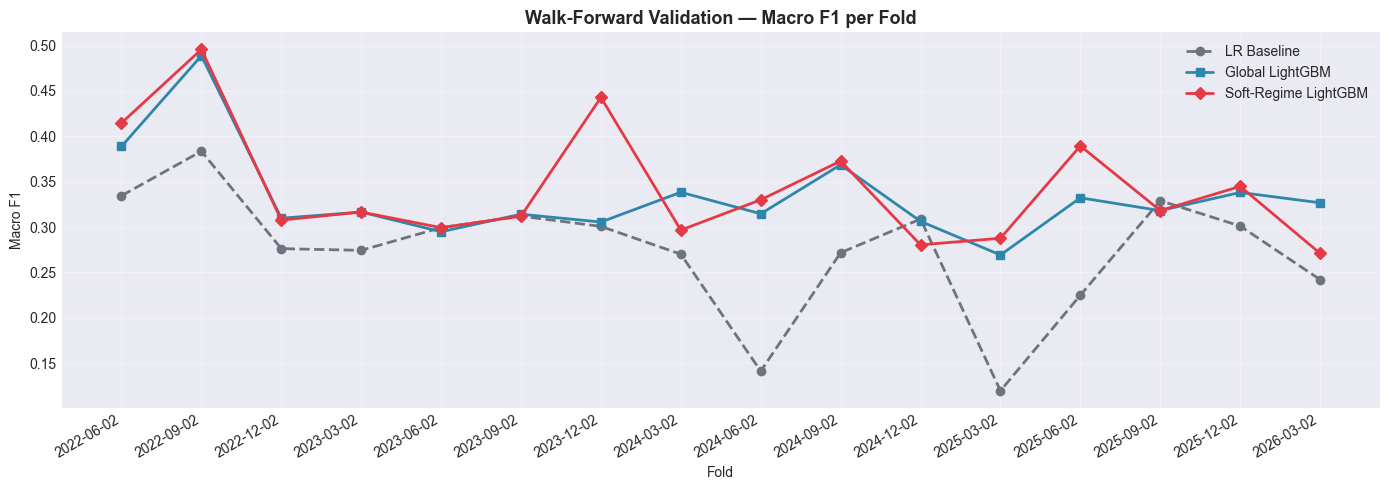

In [110]:
from src.pipeline.walk_forward import run_walk_forward, summarise_wfv

wfv_results = run_walk_forward(df_ml, best_params)
summarise_wfv(wfv_results)

x = wfv_results['fold']
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, wfv_results['lr_macro_f1'],     marker='o', color='#6c757d',
        linewidth=2, label='LR Baseline', linestyle='--')
ax.plot(x, wfv_results['global_macro_f1'], marker='s', color='#2E86AB',
        linewidth=2, label='Global LightGBM')
ax.plot(x, wfv_results['soft_macro_f1'],   marker='D', color='#E63946',
        linewidth=2, label='Soft-Regime LightGBM')
ax.set_xlabel('Fold')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward Validation — Macro F1 per Fold',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in wfv_results['test_end']],
                   rotation=30, ha='right')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 9 FINAL LIVE PREDICTION


In [111]:
proba_soft = lgbm_soft.predict_proba(X_test_soft)

In [112]:
# ==========================================
# FINAL LIVE PREDICTION
# ==========================================

latest_x = X_test_soft.iloc[[-1]]

pred_class = lgbm_soft.predict(latest_x)[0]
pred_proba = lgbm_soft.predict_proba(latest_x)[0]

class_map = {
    -1: 'SHORT (Bearish)',
     0: 'NEUTRAL',
     1: 'LONG (Bullish)'
}

predicted_label = class_map[pred_class]
confidence = np.max(pred_proba) * 100

print('\n' + '=' * 60)
print('FINAL MARKET PREDICTION')
print('=' * 60)

print(f'Prediction : {predicted_label}')
print(f'Confidence : {confidence:.2f}%')

print('\nClass Probabilities:')
print(f'SHORT   : {pred_proba[0]*100:.2f}%')
print(f'NEUTRAL : {pred_proba[1]*100:.2f}%')
print(f'LONG    : {pred_proba[2]*100:.2f}%')


FINAL MARKET PREDICTION
Prediction : SHORT (Bearish)
Confidence : 51.56%

Class Probabilities:
SHORT   : 51.56%
NEUTRAL : 26.57%
LONG    : 21.87%


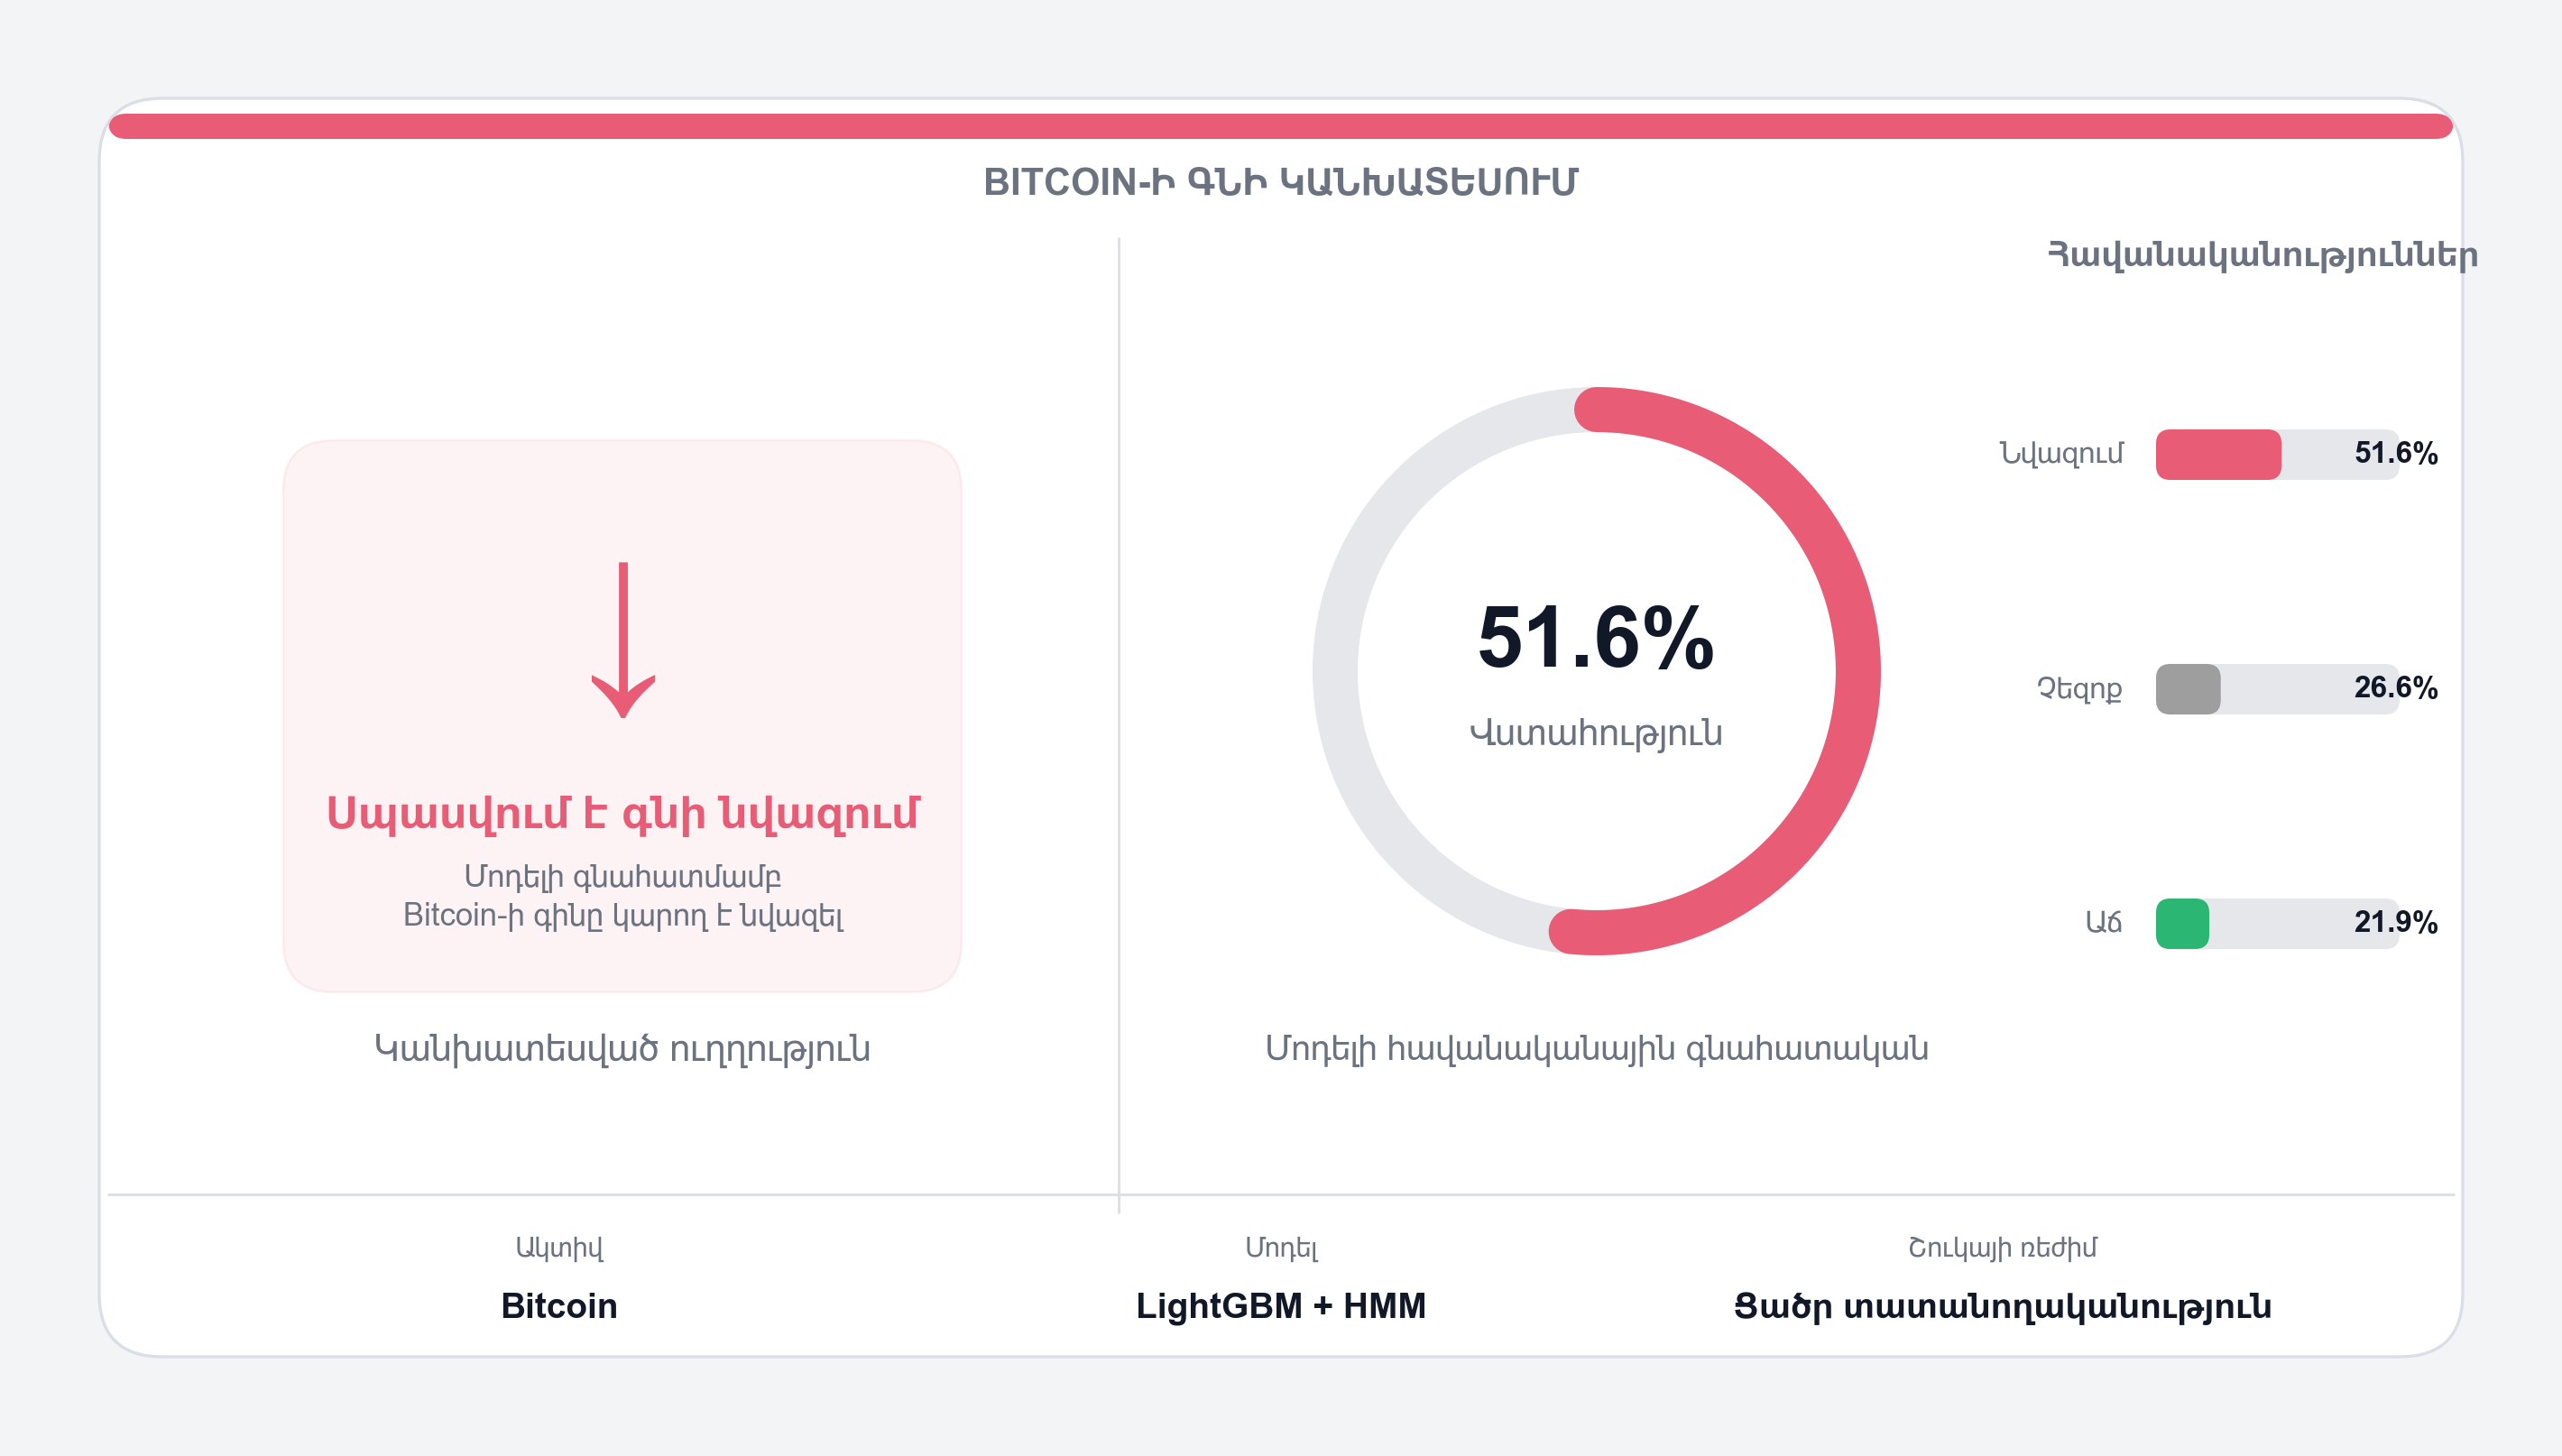

In [117]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_prediction_slide(pred_class, pred_proba, hmm_regime=None):

    CLASS_CONFIG = {
        -1: dict(
            title='Սպասվում է գնի նվազում',
            subtitle='Մոդելի գնահատմամբ\nBitcoin-ի գինը կարող է նվազել',
            icon='↓',
            color='#E85D75'
        ),
        0: dict(
            title='Հստակ ուղղություն չկա',
            subtitle='Մոդելը չի ցույց տալիս\nարտահայտված ուղղություն',
            icon='≈',
            color='#8E8E8E'
        ),
        1: dict(
            title='Սպասվում է գնի աճ',
            subtitle='Մոդելի գնահատմամբ\nBitcoin-ի գինը կարող է աճել',
            icon='↑',
            color='#2BB673'
        ),
    }

    REGIME_NAMES = {
        0: 'Ցածր տատանողականություն',
        1: 'Միջին տատանողականություն',
        2: 'Բարձր տատանողականություն'
    }

    cfg = CLASS_CONFIG[pred_class]
    confidence = float(np.max(pred_proba)) * 100

    probs = [float(p) * 100 for p in pred_proba]
    prob_labels = ['Նվազում', 'Չեզոք', 'Աճ']
    prob_colors = ['#E85D75', '#9E9E9E', '#2BB673']

    BG = '#F3F4F6'
    CARD_BG = '#FFFFFF'
    BORDER = '#D9DEE7'
    TEXT = '#111827'
    TEXT_DIM = '#6B7280'
    TRACK = '#E5E7EB'

    fig = plt.figure(figsize=(14, 7.875), dpi=200, facecolor=BG)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7.875)
    ax.axis('off')

    card = mpatches.FancyBboxPatch(
        (0.5, 0.5), 13, 6.875,
        boxstyle='round,pad=0.05,rounding_size=0.35',
        linewidth=1.2,
        edgecolor=BORDER,
        facecolor=CARD_BG,
        zorder=1
    )
    ax.add_patch(card)

    accent = mpatches.FancyBboxPatch(
        (0.5, 7.2), 13, 0.14,
        boxstyle='round,pad=0,rounding_size=0.1',
        facecolor=cfg['color'],
        edgecolor='none',
        zorder=5
    )
    ax.add_patch(accent)

    ax.text(
        7.0, 6.95,
        'BITCOIN-Ի ԳՆԻ ԿԱՆԽԱՏԵՍՈՒՄ',
        fontsize=15,
        color=TEXT_DIM,
        ha='center',
        va='center',
        fontweight='bold'
    )

    ax.plot([6.1, 6.1], [1.25, 6.65], color=BORDER, linewidth=1)
    ax.plot([0.5, 13.5], [1.35, 1.35], color=BORDER, linewidth=1)

    # LEFT PANEL
    signal_box = mpatches.FancyBboxPatch(
        (1.55, 2.55), 3.6, 2.9,
        boxstyle='round,pad=0.08,rounding_size=0.28',
        linewidth=1,
        edgecolor=cfg['color'],
        facecolor=cfg['color'],
        alpha=0.08,
        zorder=2
    )
    ax.add_patch(signal_box)

    ax.text(
        3.35, 4.45,
        cfg['icon'],
        fontsize=72,
        color=cfg['color'],
        ha='center',
        va='center',
        fontweight='bold'
    )

    ax.text(
        3.35, 3.45,
        cfg['title'],
        fontsize=18,
        color=cfg['color'],
        ha='center',
        va='center',
        fontweight='bold'
    )

    ax.text(
        3.35, 3.00,
        cfg['subtitle'],
        fontsize=12.5,
        color=TEXT_DIM,
        ha='center',
        va='center',
        linespacing=1.35
    )

    ax.text(
        3.35, 2.15,
        'Կանխատեսված ուղղություն',
        fontsize=15,
        color=TEXT_DIM,
        ha='center',
        va='center'
    )

    # MIDDLE PANEL
    cx, cy, r = 8.75, 4.25, 1.45

    theta_full = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, 300)
    ax.plot(
        cx + r * np.cos(theta_full),
        cy + r * np.sin(theta_full),
        color=TRACK,
        linewidth=18,
        solid_capstyle='round',
        zorder=3
    )

    theta_end = np.pi / 2 - 2 * np.pi * (confidence / 100)
    theta_fill = np.linspace(np.pi / 2, theta_end, 300)

    ax.plot(
        cx + r * np.cos(theta_fill),
        cy + r * np.sin(theta_fill),
        color=cfg['color'],
        linewidth=18,
        solid_capstyle='round',
        zorder=4
    )

    ax.text(
        cx, cy + 0.15,
        f'{confidence:.1f}%',
        fontsize=34,
        color=TEXT,
        ha='center',
        va='center',
        fontweight='bold'
    )

    ax.text(
        cx, cy - 0.35,
        'Վստահություն',
        fontsize=15,
        color=TEXT_DIM,
        ha='center',
        va='center'
    )

    ax.text(
        cx, 2.15,
        'Մոդելի հավանականային գնահատական',
        fontsize=14,
        color=TEXT_DIM,
        ha='center',
        va='center'
    )

    # RIGHT PANEL
    ax.text(
        12.45, 6.55,
        'Հավանականություններ',
        fontsize=14,
        color=TEXT_DIM,
        ha='center',
        va='center',
        fontweight='bold'
    )

    bar_ys = [5.45, 4.15, 2.85]
    bx_start = 11.85
    bx_max = 1.35

    for label, pct, color, y in zip(prob_labels, probs, prob_colors, bar_ys):

        ax.text(
            bx_start - 0.18, y,
            label,
            fontsize=12,
            color=TEXT_DIM,
            ha='right',
            va='center'
        )

        track = mpatches.FancyBboxPatch(
            (bx_start, y - 0.14),
            bx_max, 0.28,
            boxstyle='round,pad=0,rounding_size=0.08',
            facecolor=TRACK,
            edgecolor='none',
            zorder=3
        )
        ax.add_patch(track)

        bar_w = max((pct / 100) * bx_max, 0.03)

        fill = mpatches.FancyBboxPatch(
            (bx_start, y - 0.14),
            bar_w, 0.28,
            boxstyle='round,pad=0,rounding_size=0.08',
            facecolor=color,
            edgecolor='none',
            zorder=4
        )
        ax.add_patch(fill)

        ax.text(
            13.42, y,
            f'{pct:.1f}%',
            fontsize=12,
            color=TEXT,
            ha='right',
            va='center',
            fontweight='bold'
        )

    # FOOTER
    footer_items = [
        ('Ակտիվ', 'Bitcoin'),
        ('Մոդել', 'LightGBM + HMM')
    ]

    if hmm_regime is not None:
        footer_items.append(
            ('Շուկայի ռեժիմ', REGIME_NAMES.get(int(hmm_regime), '—'))
        )

    step = 12.0 / len(footer_items)
    x_pos = 1.0 + step / 2

    for label, value in footer_items:
        ax.text(
            x_pos, 1.05,
            label,
            fontsize=11,
            color=TEXT_DIM,
            ha='center',
            va='center'
        )
        ax.text(
            x_pos, 0.72,
            value,
            fontsize=14,
            color=TEXT,
            ha='center',
            va='center',
            fontweight='bold'
        )
        x_pos += step

    plt.show()


plot_prediction_slide(
    pred_class=pred_class,
    pred_proba=pred_proba,
    hmm_regime=int(test_regimes[-1])
)

## 10 Backtest

    Ռազմավարություն  Արդյունք %  Տարեկան %  Sharpe  Max DD %  Գործարքներ
0      Պասիվ պահում      -30.42     -29.68   -0.65    -49.53           0
1          LightGBM       -4.92      -4.13   -0.15    -19.12         154
2   Վստահության շեմ       23.47      17.25    1.63     -6.24          92
3  Շուկայի ռեժիմներ        4.11       3.29    0.30    -10.50          90
4         Համակցված        5.44       4.34    0.29    -15.56          88


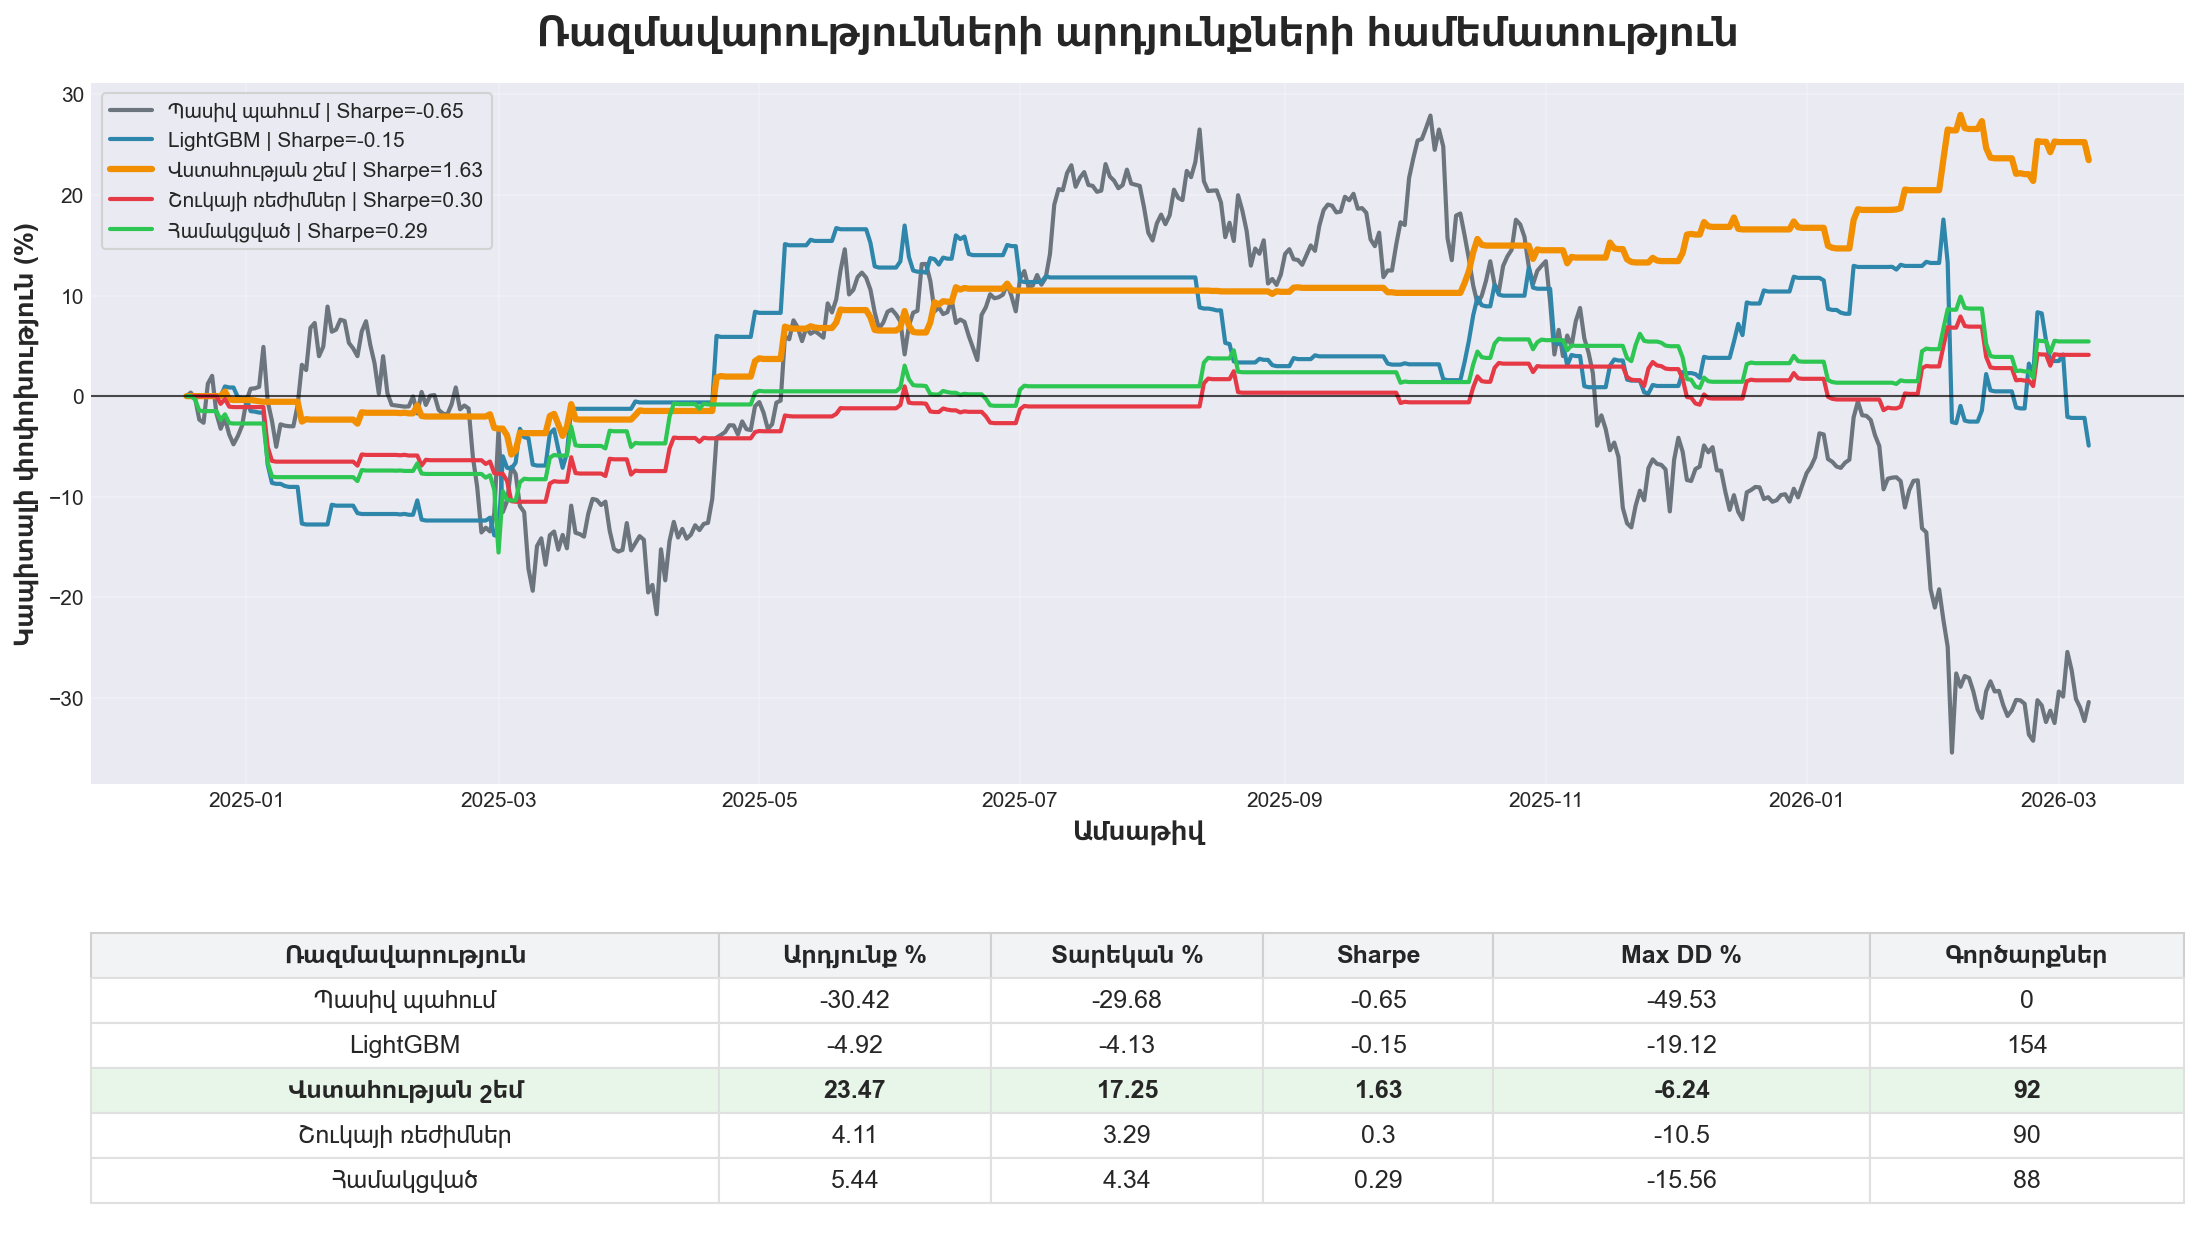

In [118]:
from src.models.backtest import (
    calculate_metrics, build_binary_position,
    build_confidence_position,
    build_regime_aware_position, build_mixed_position
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================
# 1. BACKTEST CALCULATION
# =========================

test_idx      = y_test.index
log_ret_test  = df_ml.loc[test_idx, 'future_return']
regime_test   = X_test_reg['regime'].values

lgbm_soft     = models['LightGBM Soft-Regime']
lgbm_global   = models['LightGBM Global']

pred_soft     = lgbm_soft.predict(X_test_soft)
proba_soft    = lgbm_soft.predict_proba(X_test_soft)

pred_global   = lgbm_global.predict(X_test_f)
proba_global  = lgbm_global.predict_proba(X_test_f)

pos_bah = pd.Series(1.0, index=log_ret_test.index)
pos_b   = build_binary_position(pred_global).set_axis(log_ret_test.index)
pos_c   = build_confidence_position(pred_global, proba_global).set_axis(log_ret_test.index)
pos_d   = build_regime_aware_position(pred_soft, proba_soft, regime_test).set_axis(log_ret_test.index)
pos_e   = build_mixed_position(pred_soft, proba_soft, regime_test).set_axis(log_ret_test.index)

COST_BPS = 0.001

res_a = calculate_metrics(pos_bah, log_ret_test, 'Պասիվ պահում', 0)
res_b = calculate_metrics(pos_b,   log_ret_test, 'LightGBM', COST_BPS)
res_c = calculate_metrics(pos_c,   log_ret_test, 'Վստահության շեմ', COST_BPS)
res_d = calculate_metrics(pos_d,   log_ret_test, 'Շուկայի ռեժիմներ', COST_BPS)
res_e = calculate_metrics(pos_e,   log_ret_test, 'Համակցված', COST_BPS)

all_results = [res_a, res_b, res_c, res_d, res_e]

# =========================
# 2. ARMENIAN TABLE
# =========================

bt_df = pd.DataFrame([
    {
        'Ռազմավարություն': r['Strategy'],
        'Արդյունք %': round(r['Return %'], 2),
        'Տարեկան %': round(r['Ann Ret %'], 2),
        'Sharpe': round(r['Sharpe'], 2),
        'Max DD %': round(r['Max DD %'], 2),
        'Գործարքներ': int(r['Trades'])
    }
    for r in all_results
])

print(bt_df)

# =========================
# 3. BEAUTIFUL PLOT + TABLE
# =========================

colors = ['#6c757d', '#2E86AB', '#F18F01', '#E63946', '#2dc653']

fig = plt.figure(figsize=(18, 10), dpi=150)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1.45], hspace=0.22)

# ----- Equity curve -----
ax = fig.add_subplot(gs[0])

for res, color in zip(all_results, colors):
    equity_pct = (res['Equity'] / res['Equity'].iloc[0] - 1) * 100
    
    label = f"{res['Strategy']} | Sharpe={res['Sharpe']:.2f}"
    
    lw = 3 if res['Strategy'] == 'Վստահության շեմ' else 2
    ax.plot(equity_pct.index, equity_pct, color=color, linewidth=lw, label=label)

ax.axhline(0, color='black', linewidth=1, alpha=0.7)

ax.set_title(
    'Ռազմավարությունների արդյունքների համեմատություն',
    fontsize=20,
    fontweight='bold',
    pad=18
)

ax.set_ylabel('Կապիտալի փոփոխություն (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ամսաթիվ', fontsize=13, fontweight='bold')

ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(alpha=0.25)

# ----- Table -----
ax_table = fig.add_subplot(gs[1])
ax_table.axis('off')

table = ax_table.table(
    cellText=bt_df.values,
    colLabels=bt_df.columns,
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[0.30, 0.13, 0.13, 0.11, 0.18, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

# Header style
for col in range(len(bt_df.columns)):
    cell = table[(0, col)]
    cell.set_text_props(fontweight='bold')
    cell.set_facecolor('#F1F3F5')
    cell.set_edgecolor('#D0D0D0')

# Body style
for row in range(1, len(bt_df) + 1):
    for col in range(len(bt_df.columns)):
        cell = table[(row, col)]
        cell.set_edgecolor('#E0E0E0')
        
        # Highlight best strategy row
        if bt_df.iloc[row - 1]['Ռազմավարություն'] == 'Վստահության շեմ':
            cell.set_facecolor('#E8F5E9')
            cell.set_text_props(fontweight='bold')
        else:
            cell.set_facecolor('white')

plt.tight_layout()
plt.show()